### Import libraries

In [5]:
import os
import random
import re
import shutil
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import numpy as np
import json

### Shuffling + Sorting

In [42]:
# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define the path to main dataset folder
DATASET_PATH = Path("D:/ImgProject/data")

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")

CLASSES = ['battery', 'biological', 'cardboard', 'carton', 'clothes', 
           'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']  # 11 folders

In [43]:
# Define your folders and their processing rules
FOLDERS_CONFIG = {
    "glass": {"prefix": "glass", "shuffle": True},
    "carton": {"prefix": "carton", "shuffle": False},
    "metal": {"prefix": "metal", "shuffle": False},
    "plastic": {"prefix": "plastic", "shuffle": False},
    "trash": {"prefix": "trash", "shuffle": True},
    "shoes": {"prefix": "shoes", "shuffle": False},

    # Leave unchanged
    "battery": None,
    "biological": None,
    "cardboard": None,
    "clothes": None,
    "paper": None
}


# =========================================================
# GET IMAGE FILES
# =========================================================

def get_images(folder):
    return [
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]


# =========================================================
# RENAME FOLDER SAFELY
# =========================================================

def rename_folder(folder, prefix, shuffle=False):
    files = get_images(folder)

    if not files:
        print(f"No images found in {folder.name}")
        return

    if shuffle:
        random.shuffle(files)
    else:
        files.sort()

    temp_folder = folder / "__temp__"
    temp_folder.mkdir(exist_ok=True)

    renamed_count = 0

    # Move files to temp folder first (avoids overwrite conflicts)
    for i, file in enumerate(files, 1):
        new_name = f"{prefix}{i}{file.suffix.lower()}"
        shutil.move(str(file), str(temp_folder / new_name))
        renamed_count += 1

    # Move them back
    for file in temp_folder.iterdir():
        shutil.move(str(file), str(folder / file.name))

    temp_folder.rmdir()

    print(f"{folder.name}: {renamed_count} files renamed → {prefix}1 to {prefix}{renamed_count}")


In [44]:
# =========================================================
# VERIFY DATASET
# =========================================================

def verify_dataset():
    print("\n" + "=" * 50)
    print("DATASET SUMMARY")
    print("=" * 50)

    total_images = 0

    for folder_name in FOLDERS_CONFIG:
        folder = DATASET_PATH / folder_name

        if not folder.exists():
            print(f"{folder_name}: folder not found")
            continue

        count = len(get_images(folder))
        total_images += count

        print(f"{folder_name:<12} : {count} images")

    print("=" * 50)
    print(f"Total Images: {total_images}")

In [45]:
# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    print("=" * 50)
    print("DATASET STANDARDIZATION")
    print("=" * 50)

    print("\nFolders to process:")

    for folder_name, config in FOLDERS_CONFIG.items():
        if config is None:
            print(f"- {folder_name}: leave as is")
        elif config["shuffle"]:
            print(f"- {folder_name}: shuffle + rename")
        else:
            print(f"- {folder_name}: sequential rename")

    confirm = input("\nThis will rename files. Continue? (yes/no): ").lower()

    if confirm != "yes":
        print("Operation cancelled.")
        exit()

    print("\nProcessing...\n")

    for folder_name, config in FOLDERS_CONFIG.items():
        if config is None:
            continue

        folder = DATASET_PATH / folder_name

        if not folder.exists():
            print(f"{folder_name}: folder not found")
            continue

        rename_folder(
            folder=folder,
            prefix=config["prefix"],
            shuffle=config["shuffle"]
        )

    verify_dataset()

    print("\nDataset is ready for train / validation / test split.")

DATASET STANDARDIZATION

Folders to process:
- glass: shuffle + rename
- carton: sequential rename
- metal: sequential rename
- plastic: sequential rename
- trash: shuffle + rename
- shoes: sequential rename
- battery: leave as is
- biological: leave as is
- cardboard: leave as is
- clothes: leave as is
- paper: leave as is

This will rename files. Continue? (yes/no): yes

Processing...

glass: 942 files renamed → glass1 to glass942
carton: 1047 files renamed → carton1 to carton1047
metal: 1149 files renamed → metal1 to metal1149
plastic: 1205 files renamed → plastic1 to plastic1205
trash: 1140 files renamed → trash1 to trash1140
shoes: 988 files renamed → shoes1 to shoes988

DATASET SUMMARY
glass        : 942 images
carton       : 1047 images
metal        : 1149 images
plastic      : 1205 images
trash        : 1140 images
shoes        : 988 images
battery      : 945 images
biological   : 985 images
cardboard    : 891 images
clothes      : 1034 images
paper        : 1050 images
Total I

### My practical final roadmap:

1. **Balance classes to 900 each** (recommended)
2. **Train / Validation / Test split** (preferably 80 / 10 / 10)
3. **Image Processing phase**

   * histogram analysis
   * brightness adjustment
   * contrast adjustment
   * optional denoising / edge detection
4. **Model training**

   * Use: MobileNetV2 (fast) or ResNet50 (strong) or EfficientNetB0 (excellent)
   
   * MobileNetV2 (Perfect choice):
        * faster
        * lighter
        * good accuracy
        * easier for course project

   * preferably MobileNetV2 or ResNet50

5. **Evaluation**

   * accuracy
   * precision
   * recall
   * F1-score
   * confusion matrix
6. **Report + Presentation**


## Phase 1: Balance classes to 900 images each + Train / Validation / Test Split

This is a professional step before model training.

We will do:

* keep all 11 classes
* make each class = 900 images maximum
* random selection if a folder has more than 900
* then split into:

```text
train = 80%
val = 10%
test = 10%
```

which means per class:

```text
900 → 720 train
900 → 90 val
900 → 90 test
```

This gives:

```text
Total final dataset = 9900 images
Train = 7920
Validation = 990
Test = 990
```

Excellent for our project.

---

In [46]:
# =========================================================
# CONFIGURATION
# =========================================================

random.seed(42)

SOURCE_PATH = Path("D:/ImgProject/data")

OUTPUT_PATH = Path("D:/ImgProject/split_dataset")

CLASSES = [
    "battery",
    "biological",
    "cardboard",
    "carton",
    "clothes",
    "glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash"
]

MAX_IMAGES_PER_CLASS = 900

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")

In [47]:
# =========================================================
# CREATE OUTPUT FOLDERS
# =========================================================

def create_folders():
    for split in ["train", "val", "test"]:
        for class_name in CLASSES:
            folder = OUTPUT_PATH / split / class_name
            folder.mkdir(parents=True, exist_ok=True)


# =========================================================
# GET IMAGE FILES
# =========================================================

def get_images(folder):
    return [
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

In [48]:
# =========================================================
# SPLIT DATASET
# =========================================================

def split_dataset():
    print("=" * 60)
    print("BALANCING + TRAIN / VAL / TEST SPLIT")
    print("=" * 60)

    total_train = 0
    total_val = 0
    total_test = 0

    for class_name in CLASSES:
        class_path = SOURCE_PATH / class_name

        if not class_path.exists():
            print(f"{class_name}: folder not found")
            continue

        images = get_images(class_path)

        if len(images) < MAX_IMAGES_PER_CLASS:
            print(f"{class_name}: only {len(images)} images found")
            selected_images = images
        else:
            selected_images = random.sample(images, MAX_IMAGES_PER_CLASS)

        random.shuffle(selected_images)

        total = len(selected_images)

        train_count = int(total * TRAIN_RATIO)
        val_count = int(total * VAL_RATIO)
        test_count = total - train_count - val_count

        train_files = selected_images[:train_count]
        val_files = selected_images[train_count:train_count + val_count]
        test_files = selected_images[train_count + val_count:]

        # Copy files
        for file in train_files:
            shutil.copy(file, OUTPUT_PATH / "train" / class_name / file.name)

        for file in val_files:
            shutil.copy(file, OUTPUT_PATH / "val" / class_name / file.name)

        for file in test_files:
            shutil.copy(file, OUTPUT_PATH / "test" / class_name / file.name)

        total_train += len(train_files)
        total_val += len(val_files)
        total_test += len(test_files)

        print(
            f"{class_name:<12} → "
            f"Train: {len(train_files)} | "
            f"Val: {len(val_files)} | "
            f"Test: {len(test_files)}"
        )

    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    print(f"Train Total: {total_train}")
    print(f"Validation Total: {total_val}")
    print(f"Test Total: {total_test}")
    print(f"Grand Total: {total_train + total_val + total_test}")

In [49]:
# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    create_folders()
    split_dataset()

    print("\nDataset is ready for model training.")

BALANCING + TRAIN / VAL / TEST SPLIT
battery      → Train: 720 | Val: 90 | Test: 90
biological   → Train: 720 | Val: 90 | Test: 90
cardboard: only 891 images found
cardboard    → Train: 712 | Val: 89 | Test: 90
carton       → Train: 720 | Val: 90 | Test: 90
clothes      → Train: 720 | Val: 90 | Test: 90
glass        → Train: 720 | Val: 90 | Test: 90
metal        → Train: 720 | Val: 90 | Test: 90
paper        → Train: 720 | Val: 90 | Test: 90
plastic      → Train: 720 | Val: 90 | Test: 90
shoes        → Train: 720 | Val: 90 | Test: 90
trash        → Train: 720 | Val: 90 | Test: 90

FINAL SUMMARY
Train Total: 7912
Validation Total: 989
Test Total: 990
Grand Total: 9891

Dataset is ready for model training.


### Final dataset:

```text
Train = 7912
Validation = 989
Test = 990
Total = 9891
```


---


### Dataset Preparation

“The dataset was standardized and balanced by limiting each class to a maximum of 900 images to reduce class imbalance and computational cost.
The final dataset was split into training, validation, and testing sets using an 80/10/10 ratio.”

## 📄 SHARED PDF HELPER

In [102]:
pip install reportlab


  Attempting uninstall: pillow
    Found existing installation: Pillow 8.0.1
    Uninstalling Pillow-8.0.1:
      Successfully uninstalled Pillow-8.0.1


In [19]:
import reportlab
print(reportlab.Version)

4.4.10


In [20]:
import sys
print(sys.executable)

C:\Users\HP\anaconda3\envs\imgcv\python.exe


In [21]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
import matplotlib.pyplot as plt
import cv2
import io
from pathlib import Path
import os

In [36]:
#PDF CORE UTILITIES
def create_pdf(path):
    os.makedirs(path.parent, exist_ok=True)

    pdf = SimpleDocTemplate(
        str(path),
        pagesize=A4,
        title=path.stem  # ← this sets PDF title metadata
    )

    return pdf


def add_text(elements, text):
    styles = getSampleStyleSheet()
    elements.append(Paragraph(text, styles["Normal"]))
    elements.append(Spacer(1, 10))


def fig_to_buffer():
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    plt.close()
    return buf


def cv_image_to_buffer(image):
    """Convert OpenCV image → buffer for PDF"""
    _, img_encoded = cv2.imencode('.png', image)
    return io.BytesIO(img_encoded.tobytes())

In [37]:
#1️⃣ DATA UNDERSTANDING → PDF VERSION
def run_data_understanding_pdf(image, image_path, report_path):

    pdf = create_pdf(report_path)
    elements = []

    # ================= TEXT =================
    image_type = get_image_type(image)
    resolution, bit_depth = get_image_details(image)
    brightness_value, brightness_level = analyze_brightness(image)
    blur_score, image_quality = analyze_blur(image)

    add_text(elements, "<b>DATA UNDERSTANDING REPORT</b>")
    add_text(elements, f"Image Path: {image_path}")
    add_text(elements, f"Type: {image_type}")
    add_text(elements, f"Resolution: {resolution}")
    add_text(elements, f"Bit Depth: {bit_depth}")
    add_text(elements, f"Brightness: {brightness_value:.2f} ({brightness_level})")
    add_text(elements, f"Blur Score: {blur_score:.2f} ({image_quality})")

    # ================= ORIGINAL IMAGE =================
    add_text(elements, "<b>Original Image</b>")
    elements.append(RLImage(cv_image_to_buffer(image), width=250, height=180))
    elements.append(Spacer(1, 10))

    # ================= HISTOGRAM =================
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure()
    plt.hist(gray.ravel(), bins=256)
    plt.title("Histogram")
    hist_buf = fig_to_buffer()

    add_text(elements, "<b>Histogram</b>")
    elements.append(RLImage(hist_buf, width=400, height=250))

    pdf.build(elements)

    print(f"📄 Saved successfully to PDF: {report_path}")

In [38]:
#2️⃣ IMAGE PROCESSING → PDF VERSION
# =========================================================
# FIXED IMAGE PROCESSING PDF VERSION
# - Same terminal results included in PDF
# - Correct RGB colors (no blue image issue)
# - Full professional report
# =========================================================

def run_image_processing_pdf(image, image_path, report_path):

    pdf = create_pdf(report_path)
    elements = []

    # =====================================================
    # ANALYSIS VALUES
    # =====================================================

    # Original
    original_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    original_brightness = np.mean(original_gray)

    # Brightness only
    bright = adjust_brightness(image)
    bright_gray = cv2.cvtColor(bright, cv2.COLOR_RGB2GRAY)
    bright_value = np.mean(bright_gray)

    # Contrast only
    contrast = adjust_contrast(image)
    contrast_gray = cv2.cvtColor(contrast, cv2.COLOR_RGB2GRAY)
    contrast_value = np.mean(contrast_gray)

    # Combined
    combined = adjust_both(image)
    combined_gray = cv2.cvtColor(combined, cv2.COLOR_RGB2GRAY)
    combined_value = np.mean(combined_gray)

    # =====================================================
    # REPORT TITLE
    # =====================================================

    add_text(elements, "<b>IMAGE PROCESSING REPORT</b>")
    add_text(elements, f"Image Path: {image_path}")

    # =====================================================
    # ORIGINAL
    # =====================================================

    add_text(elements, "<b>1. Original Image</b>")
    add_text(elements, f"Brightness Value: {original_brightness:.2f}")
    add_text(elements, "Observation: Original image before enhancement.")

    # IMPORTANT FIX:
    # image is already RGB → convert back to BGR only for saving buffer
    original_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    elements.append(
        RLImage(
            cv_image_to_buffer(original_bgr),
            width=250,
            height=180
        )
    )
    elements.append(Spacer(1, 10))

    plt.figure(figsize=(7, 5))
    plt.hist(original_gray.ravel(), bins=256, range=(0, 256))
    plt.title("Original Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    elements.append(
        RLImage(
            fig_to_buffer(),
            width=400,
            height=250
        )
    )

    # =====================================================
    # BRIGHTNESS ONLY
    # =====================================================

    add_text(elements, "<b>2. Brightness Adjustment</b>")
    add_text(elements, f"Brightness Value After Adjustment: {bright_value:.2f}")
    add_text(elements, "Observation: Visibility improved by increasing brightness.")

    bright_bgr = cv2.cvtColor(bright, cv2.COLOR_RGB2BGR)
    elements.append(
        RLImage(
            cv_image_to_buffer(bright_bgr),
            width=250,
            height=180
        )
    )
    elements.append(Spacer(1, 10))

    plt.figure(figsize=(7, 5))
    plt.hist(bright_gray.ravel(), bins=256, range=(0, 256))
    plt.title("Brightness Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    elements.append(
        RLImage(
            fig_to_buffer(),
            width=400,
            height=250
        )
    )

    # =====================================================
    # CONTRAST ONLY
    # =====================================================

    add_text(elements, "<b>3. Contrast Adjustment</b>")
    add_text(elements, f"Contrast Result Brightness Value: {contrast_value:.2f}")
    add_text(elements, "Observation: Contrast improved and object boundaries became clearer.")

    contrast_bgr = cv2.cvtColor(contrast, cv2.COLOR_RGB2BGR)
    elements.append(
        RLImage(
            cv_image_to_buffer(contrast_bgr),
            width=250,
            height=180
        )
    )
    elements.append(Spacer(1, 10))

    plt.figure(figsize=(7, 5))
    plt.hist(contrast_gray.ravel(), bins=256, range=(0, 256))
    plt.title("Contrast Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    elements.append(
        RLImage(
            fig_to_buffer(),
            width=400,
            height=250
        )
    )

    # =====================================================
    # COMBINED
    # =====================================================

    add_text(elements, "<b>4. Brightness + Contrast Combined</b>")
    add_text(elements, f"Combined Adjustment Brightness Value: {combined_value:.2f}")
    add_text(elements, "Observation: Best enhancement result with clearer and brighter object appearance.")

    combined_bgr = cv2.cvtColor(combined, cv2.COLOR_RGB2BGR)
    elements.append(
        RLImage(
            cv_image_to_buffer(combined_bgr),
            width=250,
            height=180
        )
    )
    elements.append(Spacer(1, 10))

    plt.figure(figsize=(7, 5))
    plt.hist(combined_gray.ravel(), bins=256, range=(0, 256))
    plt.title("Combined Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    elements.append(
        RLImage(
            fig_to_buffer(),
            width=400,
            height=250
        )
    )

    # =====================================================
    # FINAL SUMMARY
    # =====================================================

    add_text(elements, "<b>Final Insight</b>")
    add_text(
        elements,
        "Brightness and contrast enhancement improves image visibility, "
        "supports better object recognition, and helps improve classification performance."
    )

    # =====================================================
    # SAVE PDF
    # =====================================================

    pdf.build(elements)

    print(f"\n📄 Saved successfully to PDF: {report_path}")

# Next Step:

### Dataset Understanding + Sample Analysis


- Step 1 → Dataset Description

- Step 2 → Data Understanding

---

### Sample Image Analysis Code

This will help extract:

* image type (RGB / Grayscale)
* resolution
* bit depth
* brightness info
* blur estimation
* observations for report writing

This is VERY useful.

---

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [40]:
# =========================================================
# IMAGE TYPE DETECTION
# =========================================================

def get_image_type(image):
    if len(image.shape) == 2:
        return "Grayscale"
    elif len(image.shape) == 3 and image.shape[2] == 3:
        return "RGB"
    return "Unknown"


# =========================================================
# RESOLUTION + BIT DEPTH
# =========================================================

def get_image_details(image):
    height, width = image.shape[:2]
    resolution = f"{width} x {height}"

    bit_depth = image.dtype

    return resolution, bit_depth


# =========================================================
# BRIGHTNESS ANALYSIS
# =========================================================

def analyze_brightness(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)

    if brightness < 80:
        level = "Dark"
    elif brightness > 170:
        level = "Bright"
    else:
        level = "Balanced"

    return brightness, level


# =========================================================
# BLUR DETECTION
# =========================================================

def analyze_blur(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Variance of Laplacian method
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if blur_score < 100:
        quality = "Blurry"
    else:
        quality = "Clear"

    return blur_score, quality


# =========================================================
# DISPLAY SAMPLE IMAGE
# =========================================================

def show_image(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.title("Sample Image")
    plt.axis("off")
    plt.show()

DATA UNDERSTANDING - SAMPLE IMAGE ANALYSIS
Enter class name (e.g., plastic): plastic
Enter image name (e.g., plastic383.jpg): plastic1.jpg

Selected Image: D:\ImgProject\split_dataset\train\plastic\plastic1.jpg

Image Path        : D:\ImgProject\split_dataset\train\plastic\plastic1.jpg
Image Type        : RGB
Resolution        : 270 x 186
Bit Depth         : uint8
Brightness Value  : 35.22
Lighting Condition: Dark
Blur Score        : 484.60
Image Quality     : Clear

Key Observations:
- The image is a RGB image.
- Resolution is 270 x 186.
- Lighting appears dark.
- Image quality is clear.


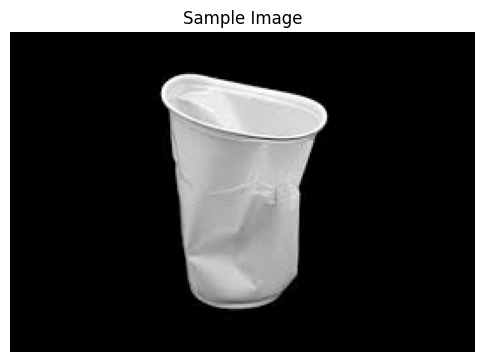


✅Sample image analysis completed successfully.
📄 Saved successfully to PDF: Reports\Data_Understanding\plastic1.pdf


In [29]:
# =========================================================
# LOAD IMAGE
# =========================================================

def load_image(path):
    image = cv2.imread(str(path))

    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")

    return image

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    
    print("=" * 60)
    print("DATA UNDERSTANDING - SAMPLE IMAGE ANALYSIS")
    print("=" * 60)

    BASE = Path("D:/ImgProject/split_dataset/train")

    class_name = input("Enter class name (e.g., plastic): ").strip().lower()
    image_name = input("Enter image name (e.g., plastic383.jpg): ").strip()

    image_path = BASE / class_name / image_name
    print(f"\nSelected Image: {image_path}")
    
    image = load_image(image_path)

    # terminal output (UNCHANGED)
    image_type = get_image_type(image) 
    resolution, bit_depth = get_image_details(image)
    brightness_value, brightness_level = analyze_brightness(image)
    blur_score, image_quality = analyze_blur(image)

    print(f"\nImage Path        : {image_path}")
    print(f"Image Type        : {image_type}")
    print(f"Resolution        : {resolution}")
    print(f"Bit Depth         : {bit_depth}")
    print(f"Brightness Value  : {brightness_value:.2f}")
    print(f"Lighting Condition: {brightness_level}")
    print(f"Blur Score        : {blur_score:.2f}")
    print(f"Image Quality     : {image_quality}")

    print("\nKey Observations:")
    print(f"- The image is a {image_type} image.")
    print(f"- Resolution is {resolution}.")
    print(f"- Lighting appears {brightness_level.lower()}.")
    print(f"- Image quality is {image_quality.lower()}.")

    show_image(image)

    print("\n✅Sample image analysis completed successfully.")

    # ================= PDF PATH =================
    report_dir = Path("Reports/Data_Understanding")
    report_name = f"{image_name.replace('.jpg','')}.pdf"
    report_path = report_dir / report_name

    run_data_understanding_pdf(image, image_path, report_path)

---

## Phase 2 → Image Processing & Analysis


- #### Histogram Analysis

- #### Brightness Adjustment

- #### Contrast Adjustment

- #### Before vs After Comparison

- #### Observations

---

### Next Coding Step

We will now write professional code for:

#### Histogram + Brightness + Contrast Analysis

using:

* OpenCV
* Matplotlib
* NumPy

This will include:

- #### Original image

- #### Histogram

- #### Brightness adjusted image

- #### Contrast adjusted image

- #### Before vs After comparison


---

In [41]:
# =========================================================
# HISTOGRAM
# =========================================================

def plot_histogram(image, title="Histogram"):
    """
    Plot grayscale histogram of an image.
    """

    # Convert safely to grayscale (handles RGB input)
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    plt.figure(figsize=(7, 5))
    plt.hist(gray.ravel(), bins=256, range=(0, 256))

    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

In [42]:
# =========================================================
# BRIGHTNESS ONLY
# =========================================================
def adjust_brightness(image, beta=40):
    """
    Increase brightness only.
    """
    return cv2.convertScaleAbs(image, alpha=1.0, beta=beta)

In [43]:
# =========================================================
# CONTRAST ONLY
# =========================================================
def adjust_contrast(image, alpha=1.4):
    """
    Increase contrast only.
    """
    return cv2.convertScaleAbs(image, alpha=alpha, beta=0)

In [44]:
# =========================================================
# BRIGHTNESS + CONTRAST ADJUSTMENT
# =========================================================

def adjust_both(image, alpha=1.4, beta=40):
    """
    Adjust both brightness and contrast.

    alpha > 1 → increase contrast
    beta > 0  → increase brightness
    """

    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

In [45]:
# =========================================================
# DISPLAY COMPARISON
# =========================================================

def compare_images(images, titles):
    """
    Display multiple images side by side.
    """

    n = len(images)
    plt.figure(figsize=(5 * n, 5))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

IMAGE PROCESSING - SEPARATE + COMBINED ANALYSIS
Enter class name (e.g., plastic): plastic
Enter image name (e.g., plastic383.jpg): plastic383.jpg

Selected Image: D:\ImgProject\split_dataset\train\plastic\plastic383.jpg


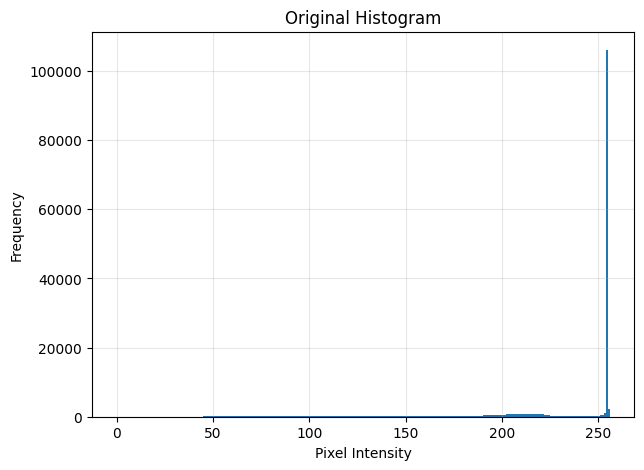

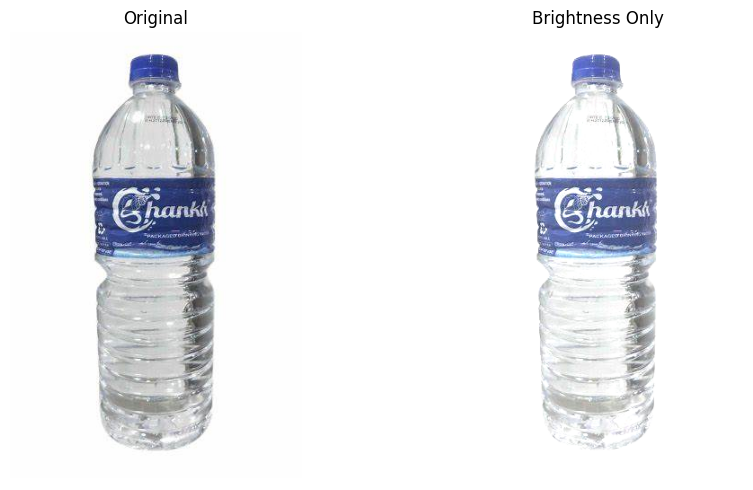

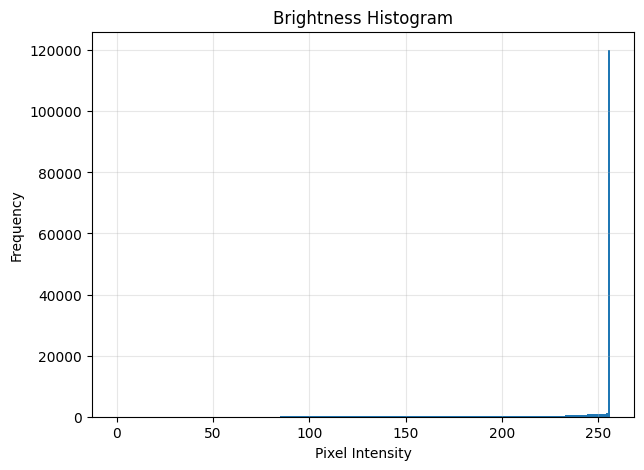

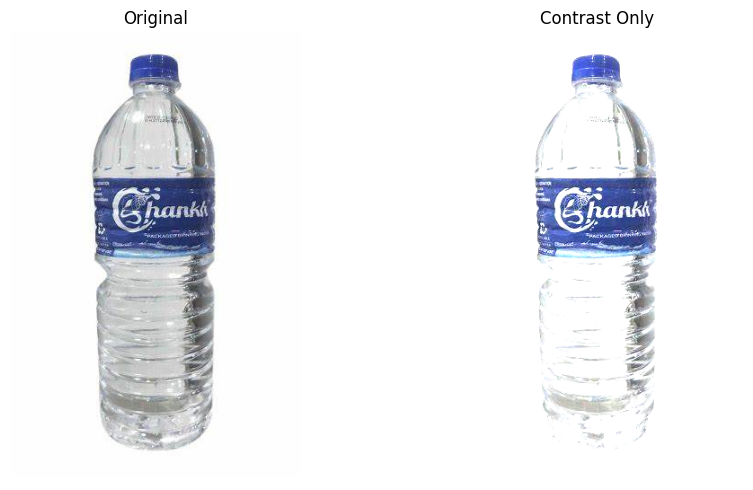

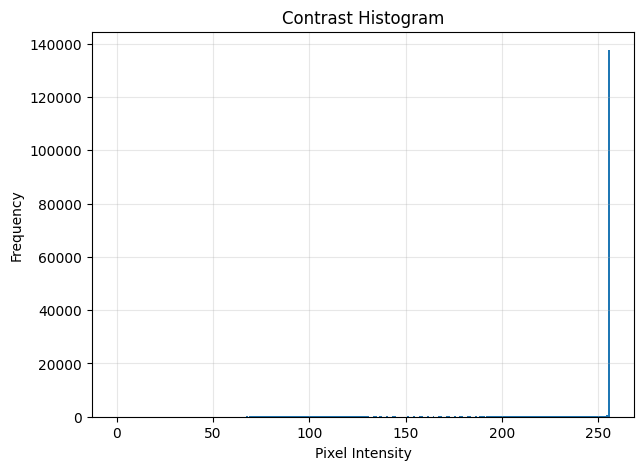

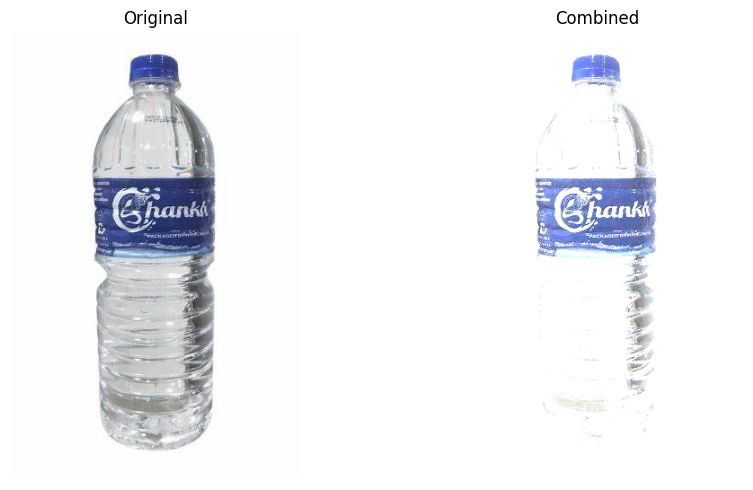

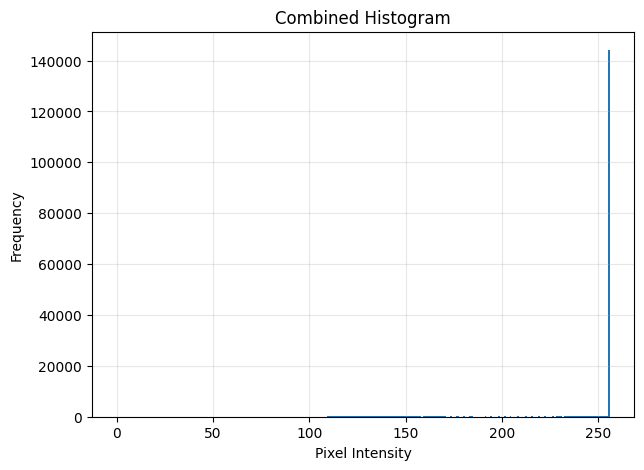


✅Image Processing analysis completed successfully.

📄 Saved successfully to PDF: Reports\Image_Processing\plastic383.pdf


In [46]:
# =========================================================
# LOAD IMAGE
# =========================================================
def load_image(path):
    """
    Load image using OpenCV and convert to RGB.
    """

    image = cv2.imread(str(path))

    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    print("=" * 60)
    print("IMAGE PROCESSING - SEPARATE + COMBINED ANALYSIS")
    print("=" * 60)

    BASE_PATH = Path("D:/ImgProject/split_dataset/train")

    class_name = input("Enter class name (e.g., plastic): ").strip().lower()
    image_name = input("Enter image name (e.g., plastic383.jpg): ").strip()

    image_path = BASE_PATH / class_name / image_name
    print(f"\nSelected Image: {image_path}")
    
    image = load_image(image_path)
    
    #terminal results
    
    # =====================================================
    # ORIGINAL
    # =====================================================
    plot_histogram(image, "Original Histogram")

    # =====================================================
    # BRIGHTNESS ONLY
    # =====================================================
    bright = adjust_brightness(image)
    compare_images([image, bright], ["Original", "Brightness Only"])
    plot_histogram(bright, "Brightness Histogram")

    # =====================================================
    # CONTRAST ONLY
    # =====================================================
    contrast = adjust_contrast(image)
    compare_images([image, contrast], ["Original", "Contrast Only"])
    plot_histogram(contrast, "Contrast Histogram")

    # =====================================================
    # COMBINED
    # =====================================================
    combined = adjust_both(image)
    compare_images([image, combined], ["Original", "Combined"])
    plot_histogram(combined, "Combined Histogram")

    print("\n✅Image Processing analysis completed successfully.")

    #report results
    report_dir = Path("Reports/Image_Processing")
    report_name = f"{image_name.replace('.jpg','')}.pdf"
    report_path = report_dir / report_name

    run_image_processing_pdf(image, image_path, report_path)